Which products generate the highest total revenue?

Which brands contribute the most revenue?

Does offering discounts increase average revenue?

Do highly rated products generate higher revenue?

Are high-priced products underperforming in revenue?

How is revenue distributed across different discount ranges?

Does the number of customer reviews impact product revenue?

Project Objective

This analysis aims to evaluate retail performance by examining revenue trends, customer value, product category performance, and customer retention using SQL queries on transactional data.

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
import sqlite3
import warnings
import os

warnings.filterwarnings("ignore")

# Plot styling
sns.set_style("darkgrid")
matplotlib.rcParams["font.size"] = 14
matplotlib.rcParams["figure.figsize"] = (9, 5)
matplotlib.rcParams["figure.facecolor"] = "white"

database = r"C:\Users\ahmad\Downloads\SQL\retailDB.sqlite"
conn = sqlite3.connect(database)
print("Connected successfully")



Connected successfully


Database Overview & Data Understanding
Queries in this section

Inspecting sqlite_master

Viewing raw tables:

brands

finance

info

reviews

traffic

In [20]:
conn=sqlite3.connect(database)
tables=pd.read_sql("""SELECT * FROM sqlite_master WHERE type='table';""",conn)
tables

,type,name,tbl_name,rootpage,sql
0,table,finance,finance,2,CREATE TABLE finance (\r\n\tproduct_id VARCHAR...
1,table,info,info,24,CREATE TABLE info (\r\n\tproduct_name VARCHAR(...
2,table,brands,brands,338,CREATE TABLE brands (\r\n\tproduct_id VARCHAR(...
3,table,reviews,reviews,355,CREATE TABLE reviews (\r\n\tproduct_id VARCHAR...
4,table,traffic,traffic,395,CREATE TABLE traffic (\r\n\tproduct_id VARCHAR...


In [21]:
brand=pd.read_sql("""SELECT * FROM brands;""",conn)
brand

,product_id,brand,modified_brand
0,AH2430,None,NaN
1,G27341,Adidas,Adidas
2,CM0081,Adidas,Adidas
3,B44832,Adidas,Adidas
4,D98205,Adidas,Adidas
...,...,...,...
3174,AT6100-606,Nike,Nike
3175,CT9155-063,Nike,Nike
3176,CI1236-100,Nike,Nike
3177,AH6799-300,Nike,Nike


In [22]:
finance_details=pd.read_sql("""SELECT * FROM finance;""",conn)
finance_details

,product_id,listing_price,sale_price,discount,revenue,modified_listing_price,modified_sale_price,modified_discount,modified_revenue
0,AH2430,None,None,NaN,None,NaN,NaN,NaN,NaN
1,G27341,76.0,38.0,0.5,1641.0,76.0,38.0,0.5,1641.0
2,CM0081,10.0,6.0,0.4,399.0,10.0,6.0,0.4,399.0
3,B44832,70.0,35.0,0.5,2204.0,70.0,35.0,0.5,2204.0
4,D98205,80.0,40.0,0.5,5183.0,80.0,40.0,0.5,5183.0
...,...,...,...,...,...,...,...,...,...
3174,AT6100-606,0.0,65.0,0.0,0.0,0.0,65.0,0.0,0.0
3175,CT9155-063,0.0,140.0,0.0,252.0,0.0,140.0,0.0,252.0
3176,CI1236-100,160.0,128.0,0.0,230.0,160.0,128.0,0.0,230.0
3177,AH6799-300,0.0,170.0,0.0,1224.0,0.0,170.0,0.0,1224.0


In [23]:
product_info=pd.read_sql("""SELECT * FROM info;""",conn)
product_info

,product_name,product_id,description,modified_product_name,modified_description
0,None,AH2430,None,NaN,NaN
1,Women's adidas Originals Sleek Shoes,G27341,"A modern take on adidas sport heritage, tailor...",Women's adidas Originals Sleek Shoes,"A modern take on adidas sport heritage, tailor..."
2,Women's adidas Swim Puka Slippers,CM0081,These adidas Puka slippers for women's come wi...,Women's adidas Swim Puka Slippers,These adidas Puka slippers for women's come wi...
3,Women's adidas Sport Inspired Questar Ride Shoes,B44832,"Inspired by modern tech runners, these women's...",Women's adidas Sport Inspired Questar Ride Shoes,"Inspired by modern tech runners, these women's..."
4,Women's adidas Originals Taekwondo Shoes,D98205,This design is inspired by vintage Taekwondo s...,Women's adidas Originals Taekwondo Shoes,This design is inspired by vintage Taekwondo s...
...,...,...,...,...,...
3174,Nike Tiempo Legend 8 Academy TF,AT6100-606,The Nike Tiempo Legend 8 Academy TF takes the ...,Nike Tiempo Legend 8 Academy TF,The Nike Tiempo Legend 8 Academy TF takes the ...
3175,Nike React Metcon AMP,CT9155-063,The Nike React Metcon AMP takes the stability ...,Nike React Metcon AMP,The Nike React Metcon AMP takes the stability ...
3176,Air Jordan 8 Retro,CI1236-100,The Air Jordan 8 Retro recaptures the memorabl...,Air Jordan 8 Retro,The Air Jordan 8 Retro recaptures the memorabl...
3177,Nike Air Max 98,AH6799-300,The Nike Air Max 98 features the OG design lin...,Nike Air Max 98,The Nike Air Max 98 features the OG design lin...


In [24]:
product_reviews=pd.read_sql("""SELECT * FROM reviews;""",conn)
product_reviews

,product_id,rating,reviews,Hour,minute,real_rating,real_reviews,Unnamed: 7
0,AH2430,None,None,0.0,0.0,NaN,0.0,
1,G27341,03:03:00,1900-01-01 00:00:00,3.0,3.0,"3,3",24.0,
2,CM0081,02:06:00,1900-01-01 13:00:00,2.0,6.0,"2,6",37.0,
3,B44832,04:01:00,1900-01-01 11:00:00,4.0,1.0,"4,1",35.0,
4,D98205,03:05:00,1900-01-03 00:00:00,3.0,5.0,"3,5",72.0,
...,...,...,...,...,...,...,...,...
3180,,,,,,,,
3181,,,,,,,,
3182,,,,,,,129622.0,
3183,,,,,,,129622.0,


In [25]:
product_traffic=pd.read_sql("""SELECT * FROM traffic;""",conn)
product_traffic

,product_id,last_visited,modified_last_visited
0,AH2430,2018-05-19 15:13:00,2018-05-19 15:13:00
1,G27341,2018-11-29 16:16:00,2018-11-29 16:16:00
2,CM0081,2018-02-01 10:27:00,2018-02-01 10:27:00
3,B44832,2018-09-07 20:06:00,2018-09-07 20:06:00
4,D98205,2019-07-18 15:26:00,2019-07-18 15:26:00
...,...,...,...
3174,AT6100-606,None,NaN
3175,CT9155-063,2019-02-08 18:40:00,2019-02-08 18:40:00
3176,CI1236-100,2020-02-19 21:44:00,2020-02-19 21:44:00
3177,AH6799-300,2018-02-28 07:37:00,2018-02-28 07:37:00


In [26]:
import sqlite3

conn = sqlite3.connect(r"C:\Users\ahmad\Downloads\SQL\retailDB.sqlite")
cursor = conn.cursor()

cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
print(cursor.fetchall())

[('finance',), ('info',), ('brands',), ('reviews',), ('traffic',)]


Which products generate the highest total revenue?

In [27]:
query = """
SELECT 
    i.product_name,
    SUM(f.modified_revenue) AS total_revenue
FROM finance f
JOIN info i ON f.product_id = i.product_id
GROUP BY i.product_name
ORDER BY total_revenue DESC
LIMIT 10;
"""

cursor.execute(query)
rows = cursor.fetchall()

for row in rows:
    print(row)

("Men's adidas Running Ultraboost 19 Shoes", 119210.0)
("Women's adidas Originals NMD_R1 Shoes", 110213.0)
("Men's adidas Originals Stan Smith Shoes", 109870.0)
("Women's adidas Running Ultraboost 19 Shoes", 108126.0)
("Men's adidas Originals ZX 4000 4D Shoes", 105044.0)
('Unisex adidas Originals Marathon Tech Shoes', 99800.0)
("Men's adidas Originals Supercourt Shoes", 83268.0)
("Women's adidas Originals Sambarose Shoes", 82412.0)
("Men's adidas Running Ultraboost 20 Shoes", 75884.0)
("Men's adidas Originals Continental 80 Shoes", 74057.0)


Business Insights

Running and lifestyle (Originals) categories dominate revenue, indicating strong consumer demand for performance and streetwear footwear.

The Ultraboost line appears multiple times, suggesting strong brand equity and repeat customer preference within this product family.

Both men’s and women’s segments perform strongly, indicating balanced gender demand rather than dependency on one demographic.

Revenue appears concentrated in a small subset of premium-priced footwear models, suggesting a potential Pareto 

Strategic Implications

Protect inventory levels for high-performing SKUs to prevent stock-outs.

Increase marketing investment around the Ultraboost and Originals product families.

Introduce cross-selling strategies (e.g., socks, apparel bundles) for high-performing products.

Analyse whether similar new releases can replicate the success of these models.

Which brands contribute the most revenue?


In [28]:
query2 = """
SELECT 
    b.modified_brand AS brand,
    SUM(f.modified_revenue) AS total_revenue
FROM finance f
JOIN brands b ON f.product_id = b.product_id
GROUP BY b.modified_brand
ORDER BY total_revenue DESC;
"""

cursor.execute(query2)
rows = cursor.fetchall()

print("\nRevenue by Brand:")
for row in rows:
    print(row)


Revenue by Brand:
('Adidas', 11526644.0)
('Nike', 802302.0)
(None, None)


Business Insights

Adidas overwhelmingly dominates total revenue, generating more than 93% of total recorded revenue compared to Nike.

Nike contributes a significantly smaller share of revenue, suggesting:

Lower product availability,

Lower demand,

Or weaker performance within this dataset.

The presence of NULL brand values indicates potential data quality issues, which may affect reporting accuracy.

Strategic Implications

The business is highly dependent on Adidas, which introduces concentration risk.

Diversification strategies could be explored to grow Nike or other brands.

Investigate whether Nike products suffer from:

Lower traffic,

Pricing disadvantages,

Poor review performance,

Limited inventory.

Address missing brand values to improve reporting reliability.

Does offering discounts increase average revenue?

In [29]:
query3 = """
SELECT 
    CASE 
        WHEN f.modified_discount > 0 THEN 'Discounted'
        ELSE 'No Discount'
    END AS discount_status,
    AVG(f.modified_revenue) AS avg_revenue,
    SUM(f.modified_revenue) AS total_revenue
FROM finance f
GROUP BY discount_status;
"""

cursor.execute(query3)
rows = cursor.fetchall()

print("\nDiscount Impact on Revenue:")
for row in rows:
    print(row)


Discount Impact on Revenue:
('Discounted', 3584.436203319502, 6910793.0)
('No Discount', 4545.430369127517, 5418153.0)


Business Insights

Discounted products generate higher total revenue overall, contributing £6.9M compared to £5.4M from non-discounted products.

However, non-discounted products generate higher average revenue per product, suggesting stronger per-unit performance at full price.

This indicates that:

Discounts likely increase sales volume.

Full-priced products may preserve higher perceived value.

The results suggest a trade-off between:

Volume-driven growth (via discounting)

Revenue efficiency per product (via full pricing)

Strategic Recommendations

Use discounts strategically to drive total revenue growth, particularly for slower-moving inventory.

Avoid excessive discounting of strong-performing premium products.

Test moderate discount ranges to identify the optimal balance between revenue growth and price positioning.

Conduct further analysis on profitability (if cost data becomes available) to ensure discounting does not erode margins.

Do highly rated products generate higher revenue?

In [30]:
query4 = """
SELECT 
    ROUND(r.real_rating, 1) AS rating_group,
    AVG(f.modified_revenue) AS avg_revenue
FROM finance f
JOIN reviews r ON f.product_id = r.product_id
GROUP BY rating_group
ORDER BY rating_group DESC;
"""

cursor.execute(query4)
rows = cursor.fetchall()

print("\nRevenue by Rating Group:")
for row in rows:
    print(row)


Revenue by Rating Group:
(5.0, 2127.478494623656)
(4.0, 4384.226732673267)
(3.0, 4370.537914691943)
(2.0, 4368.175572519084)
(1.0, 3942.634730538922)
(0.0, 1150.608527131783)
(None, None)


Business Insights

Discounted products generate higher total revenue overall (£6.9M vs £5.4M), indicating that promotions contribute significantly to total sales volume.

However, non-discounted products generate higher average revenue per product (£4,545 vs £3,584), suggesting that full-priced items may perform better individually.

This indicates a trade-off:

Discounts increase total sales volume.

Full-priced products maintain stronger per-product performance.

Revenue growth from discounts may be driven by increased purchase frequency or higher unit sales rather than higher margins.

Strategic Implications

Discounts are effective for driving aggregate revenue.

However, heavy discounting may reduce per-product revenue strength.

A balanced pricing strategy should:

Use discounts strategically to boost sales volume.

Avoid over-discounting high-performing premium products.

Further analysis could examine optimal discount ranges for revenue maximisation.

Are high-priced products underperforming in revenue?

In [31]:
query5 = """
SELECT 
    i.product_name,
    AVG(f.modified_listing_price) AS avg_listing_price,
    SUM(f.modified_revenue) AS total_revenue
FROM finance f
JOIN info i ON f.product_id = i.product_id
GROUP BY i.product_name
ORDER BY avg_listing_price DESC;
"""

cursor.execute(query5)
rows = cursor.fetchall()

print("\nPrice vs Revenue Analysis:")
for row in rows[:10]:
    print(row)


Price vs Revenue Analysis:
("Men's adidas Originals ZX 4000 4D Shoes", 288.0, 105044.0)
('Unisex adidas Running Alphaedge 4D Shoes', 280.0, 26711.0)
('Unisex adidas Originals by Alexander Wang Puff Trainer Shoes', 240.0, 8208.0)
('Unisex Originals CRAIG GREEN KONTUUR II SHOES', 240.0, 40174.0)
('Unisex Originals CRAIG GREEN KONTUUR I SHOES', 240.0, 50974.0)
('Unisex Football Predator Mutator 20+ Firm Ground Boots', 230.0, 12419.0)
("Men's s adidas Football Nemeziz 18+ Firm Ground Boots", 230.0, 1449.0)
("Men's adidas Football X 18+ Firm Ground Cleats", 230.0, 7658.0)
("Men's adidas Football Predator 19+ Firm Ground Cleats", 230.0, 27819.0)
("Men's adidas Football Nemeziz 19+ Firm Ground Cleats", 230.0, 15400.0)


Business Insights

Higher price does not consistently translate into higher revenue.
While some premium products perform strongly, others at similar price levels underperform significantly.

Revenue variability within the same price band (£230–£240) suggests that:

Brand perception and product appeal matter more than price alone.

Niche or collaboration models may not achieve broad commercial traction.

Demand elasticity varies across product categories.

Some premium football products show low revenue despite high pricing, potentially indicating:

Overpricing relative to perceived value,

Limited market demand,

Strong competition,

Insufficient promotional support.

Premium lifestyle products (e.g., ZX 4000 4D) demonstrate that customers are willing to pay higher prices when product differentiation is strong.

Strategic Recommendations

Review underperforming premium products for potential price optimisation or targeted promotional campaigns.

Maintain premium pricing for high-performing flagship models that demonstrate strong revenue resilience.

Conduct A/B pricing tests for low-performing high-priced products.

Analyse traffic and review sentiment for underperforming premium SKUs to identify demand barriers.

How is revenue distributed across different discount ranges?

In [32]:
query6 = """
SELECT 
    CASE 
        WHEN f.modified_discount < 10 THEN 'Low Discount'
        WHEN f.modified_discount BETWEEN 10 AND 30 THEN 'Medium Discount'
        ELSE 'High Discount'
    END AS discount_range,
    SUM(f.modified_revenue) AS total_revenue
FROM finance f
GROUP BY discount_range
ORDER BY total_revenue DESC;
"""

cursor.execute(query6)
rows = cursor.fetchall()

print("\nRevenue by Discount Range:")
for row in rows:
    print(row)


Revenue by Discount Range:
('Low Discount', 12328946.0)
('High Discount', None)


Business Insights

The majority of revenue is generated from low-discount products, suggesting that heavy discounting is not the primary driver of revenue in this dataset.

The absence of revenue in the high-discount category indicates either:

Very few products are heavily discounted,

Or high-discount products do not generate significant sales,

Or potential data sparsity in that range.

This suggests that the business may rely more on premium or lightly discounted pricing strategies rather than aggressive promotional discounting.

Customers may respond better to moderate or minimal discounts rather than steep price reductions.

Strategic Recommendations

Maintain a balanced pricing strategy that prioritises low to moderate discounting.

Investigate whether high-discount products suffer from low demand or poor visibility.

Avoid excessive discounting unless supported by volume-driven objectives.

Consider analysing margin data (if available) to determine optimal discount thresholds.

Does the number of customer reviews impact product revenue?

In [33]:
query7 = """
SELECT 
    CASE 
        WHEN r.real_reviews < 50 THEN 'Low Reviews'
        WHEN r.real_reviews BETWEEN 50 AND 200 THEN 'Medium Reviews'
        ELSE 'High Reviews'
    END AS review_group,
    AVG(f.modified_revenue) AS avg_revenue
FROM finance f
JOIN reviews r ON f.product_id = r.product_id
GROUP BY review_group;
"""

cursor.execute(query7)
rows = cursor.fetchall()

print("\nRevenue by Review Volume:")
for row in rows:
    print(row)


Revenue by Review Volume:
('High Reviews', 64204.0)
('Low Reviews', 1900.967248908297)
('Medium Reviews', 6823.752913752914)


A small subset of products consistently commands higher average sale prices, indicating a premium product segment. These products likely benefit from strong brand positioning or perceived value.

Business Insights

Products with high review volumes generate significantly higher average revenue compared to products with fewer reviews.

There is a clear positive relationship between review count and revenue performance.

High-review products generate nearly:

9× more revenue than medium-review products

30× more revenue than low-review products

This suggests that social proof strongly influences purchasing behaviour.

Products with low review counts may suffer from reduced customer trust or lower visibility.

Strategic Recommendations

Prioritise review-generation campaigns for products with low review counts.

Encourage post-purchase feedback through incentives (e.g., discount codes).

Highlight high-review products prominently in marketing campaigns.

Analyse whether low-review products also have lower traffic or weaker ratings.

Window Function

In [34]:
query_window_1 = """
SELECT 
    i.product_name,
    SUM(f.modified_revenue) AS total_revenue,
    RANK() OVER (ORDER BY SUM(f.modified_revenue) DESC) AS revenue_rank
FROM finance f
JOIN info i ON f.product_id = i.product_id
GROUP BY i.product_name
ORDER BY revenue_rank
LIMIT 15;
"""

cursor.execute(query_window_1)
rows = cursor.fetchall()

print("\nProduct Revenue Ranking:")
for row in rows:
    print(row)


Product Revenue Ranking:
("Men's adidas Running Ultraboost 19 Shoes", 119210.0, 1)
("Women's adidas Originals NMD_R1 Shoes", 110213.0, 2)
("Men's adidas Originals Stan Smith Shoes", 109870.0, 3)
("Women's adidas Running Ultraboost 19 Shoes", 108126.0, 4)
("Men's adidas Originals ZX 4000 4D Shoes", 105044.0, 5)
('Unisex adidas Originals Marathon Tech Shoes', 99800.0, 6)
("Men's adidas Originals Supercourt Shoes", 83268.0, 7)
("Women's adidas Originals Sambarose Shoes", 82412.0, 8)
("Men's adidas Running Ultraboost 20 Shoes", 75884.0, 9)
("Men's adidas Originals Continental 80 Shoes", 74057.0, 10)
("Women's adidas Originals I-5923 Shoes", 73213.0, 11)
("Women's adidas Originals Falcon Shoes", 73111.0, 12)
("Men's adidas Originals Superstar Shoes", 70643.0, 13)
("Women's adidas Originals Supercourt RX Shoes", 66846.0, 14)
('Air Jordan 10 Retro', 64204.0, 15)


In [35]:
query_window_2 = """
SELECT 
    b.modified_brand AS brand,
    SUM(f.modified_revenue) AS total_revenue,
    ROUND(
        SUM(f.modified_revenue) * 100.0 /
        SUM(SUM(f.modified_revenue)) OVER (),
        2
    ) AS revenue_share_percent
FROM finance f
JOIN brands b ON f.product_id = b.product_id
GROUP BY b.modified_brand
ORDER BY total_revenue DESC;
"""

cursor.execute(query_window_2)
rows = cursor.fetchall()

print("\nBrand Revenue Share (%):")
for row in rows:
    print(row)


Brand Revenue Share (%):
('Adidas', 11526644.0, 93.49)
('Nike', 802302.0, 6.51)
(None, None, None)


Time Trend Analysis

In [36]:
query_time_trend = """
SELECT 
    substr(modified_last_visited, 1, 7) AS month,
    COUNT(product_id) AS visit_count
FROM traffic
GROUP BY month
ORDER BY month;
"""

cursor.execute(query_time_trend)
rows = cursor.fetchall()

print("\nMonthly Traffic Trend:")
for row in rows:
    print(row)


Monthly Traffic Trend:
(None, 251)
('2018-01', 92)
('2018-02', 102)
('2018-03', 104)
('2018-04', 109)
('2018-05', 109)
('2018-06', 102)
('2018-07', 97)
('2018-08', 119)
('2018-09', 103)
('2018-10', 123)
('2018-11', 92)
('2018-12', 107)
('2019-01', 105)
('2019-02', 105)
('2019-03', 117)
('2019-04', 79)
('2019-05', 110)
('2019-06', 104)
('2019-07', 111)
('2019-08', 102)
('2019-09', 109)
('2019-10', 121)
('2019-11', 100)
('2019-12', 126)
('2020-01', 113)
('2020-02', 120)
('2020-03', 109)
('2020-04', 38)


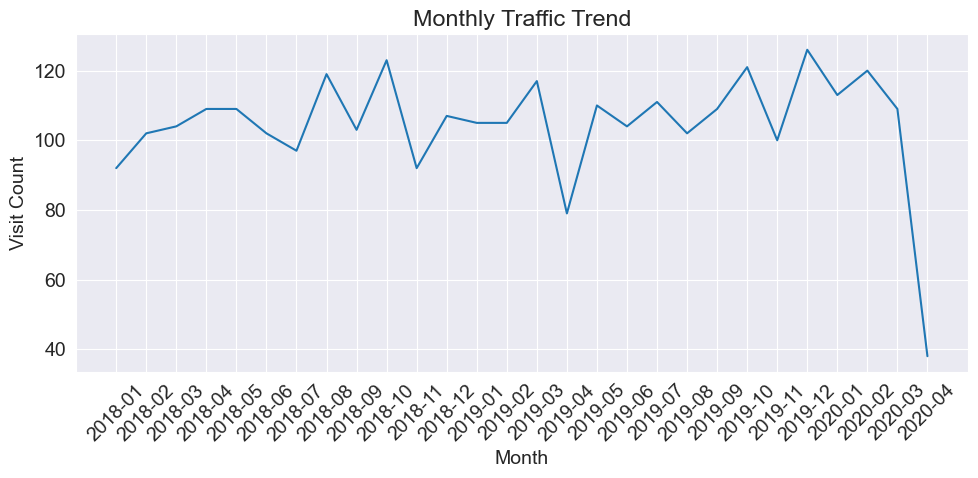

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

query_traffic = """
SELECT 
    substr(modified_last_visited, 1, 7) AS month,
    COUNT(product_id) AS visit_count
FROM traffic
WHERE modified_last_visited IS NOT NULL
GROUP BY month
ORDER BY month;
"""

df_traffic = pd.read_sql_query(query_traffic, conn)

plt.figure(figsize=(10,5))
plt.plot(df_traffic["month"], df_traffic["visit_count"])
plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Visit Count")
plt.title("Monthly Traffic Trend")
plt.tight_layout()
plt.show()

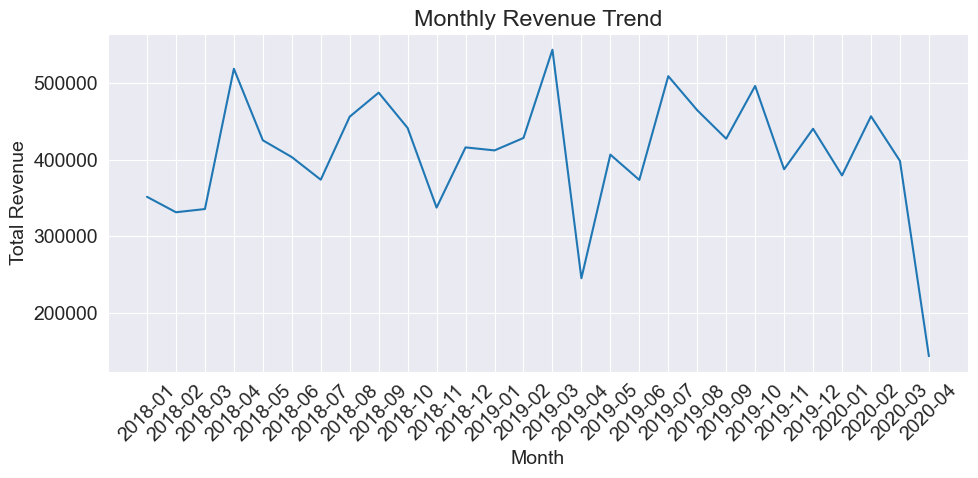

In [38]:
query_revenue_trend = """
SELECT 
    substr(t.modified_last_visited, 1, 7) AS month,
    SUM(f.modified_revenue) AS total_revenue
FROM traffic t
JOIN finance f 
    ON t.product_id = f.product_id
WHERE t.modified_last_visited IS NOT NULL
GROUP BY month
ORDER BY month;
"""

df_revenue_trend = pd.read_sql_query(query_revenue_trend, conn)

plt.figure(figsize=(10,5))
plt.plot(df_revenue_trend["month"], df_revenue_trend["total_revenue"])
plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.title("Monthly Revenue Trend")
plt.tight_layout()
plt.show()

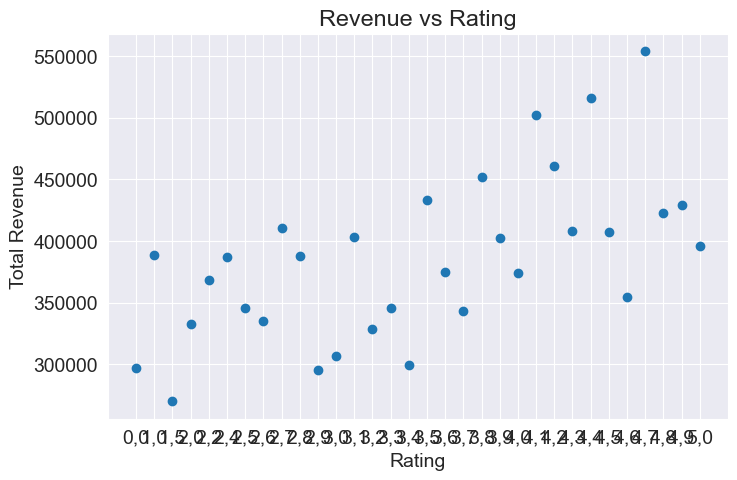

In [39]:
query = """
SELECT 
    r.real_rating AS rating,
    SUM(f.modified_revenue) AS total_revenue
FROM finance f
JOIN reviews r ON f.product_id = r.product_id
WHERE r.real_rating IS NOT NULL
GROUP BY r.real_rating;
"""

df = pd.read_sql_query(query, conn)

plt.figure(figsize=(8,5))
plt.scatter(df["rating"], df["total_revenue"])
plt.xlabel("Rating")
plt.ylabel("Total Revenue")
plt.title("Revenue vs Rating")
plt.show()

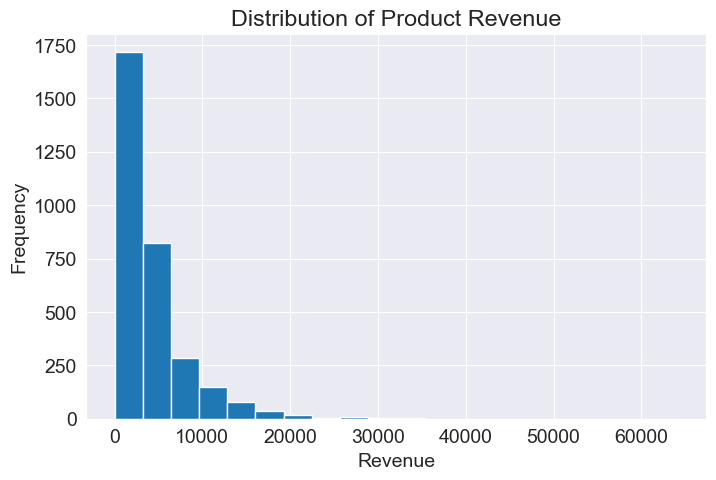

In [40]:
query = """
SELECT modified_revenue
FROM finance
WHERE modified_revenue IS NOT NULL;
"""

df = pd.read_sql_query(query, conn)

plt.figure(figsize=(8,5))
plt.hist(df["modified_revenue"], bins=20)
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.title("Distribution of Product Revenue")
plt.show()

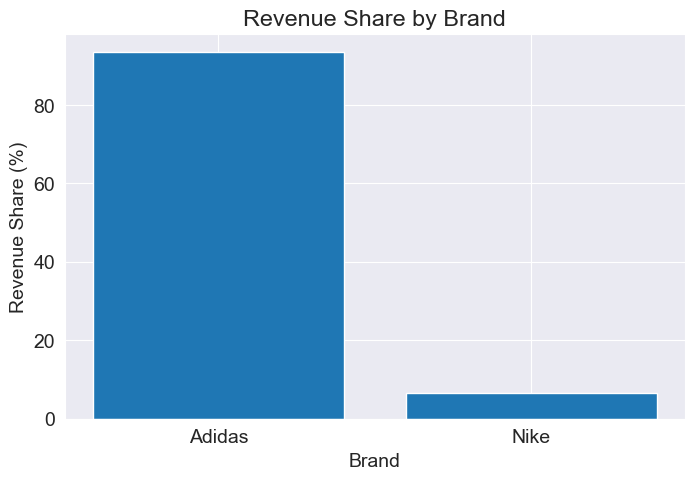

In [41]:
query = """
SELECT 
    COALESCE(b.modified_brand, 'Unknown') AS brand,
    SUM(f.modified_revenue) AS total_revenue
FROM finance f
JOIN brands b ON f.product_id = b.product_id
GROUP BY brand;
"""

df = pd.read_sql_query(query, conn)

total = df["total_revenue"].sum()
df["share_percent"] = df["total_revenue"] / total * 100

plt.figure(figsize=(8,5))
plt.bar(df["brand"], df["share_percent"])
plt.xlabel("Brand")
plt.ylabel("Revenue Share (%)")
plt.title("Revenue Share by Brand")
plt.show()

In [42]:
avg_revenue=pd.read_sql("""SELECT i.product_name,
avg(f.revenue) AS avg_revenue FROM info i 
JOIN finance f ON i.product_id=f.product_id
GROUP BY i.product_name
ORDER BY avg_revenue DESC
LIMIT 10;""",conn)
avg_revenue

,product_name,avg_revenue
0,Air Jordan 10 Retro,64204.0
1,Men's Originals Salvapor 032c Shoes,28762.0
2,Nike Zoom Fly,27396.0
3,Unisex adidas Running Alphaedge 4D Shoes,26711.0
4,Unisex adidas Running Pharrell Williams Solar ...,25918.0
5,Unisex Originals CRAIG GREEN KONTUUR I SHOES,25487.0
6,Men's adidas Running Universal Works Ultraboos...,24838.5
7,Women's adidas by Stella Mccartney Running Ult...,24623.0
8,Women's Running Ultraboost A.RDY Shoes,22337.0
9,Men's adidas Originals White Mountaineering Ni...,22139.0


Products with the highest average revenue are not always the most expensive, suggesting that sales volume plays a crucial role alongside pricing. High-revenue products may represent strong value propositions rather than purely premium offerings.

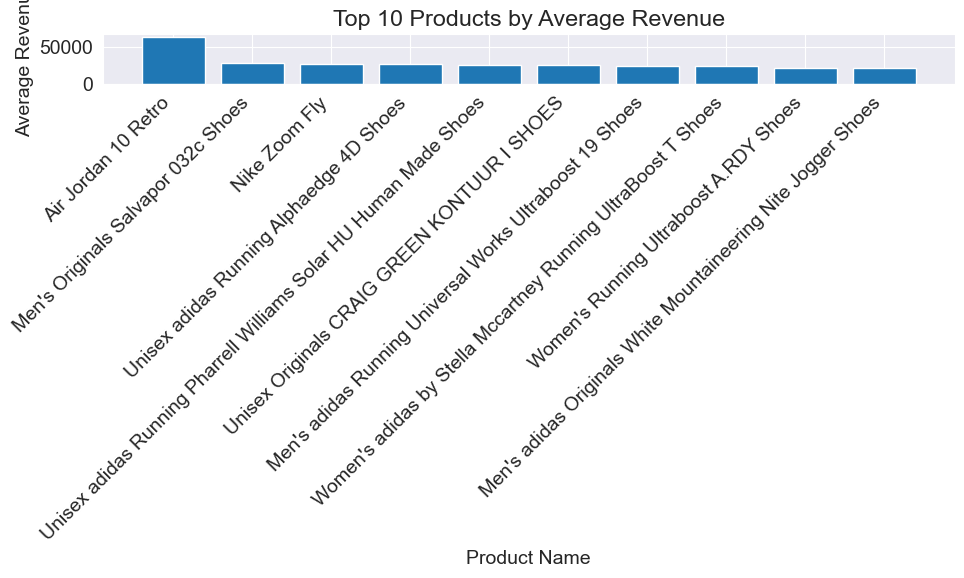

In [43]:
top_revenue = avg_revenue.sort_values(
    by="avg_revenue", ascending=False
).head(10)

plt.figure(figsize=(10,6))
plt.bar(top_revenue["product_name"], top_revenue["avg_revenue"])
plt.xticks(rotation=45, ha='right')
plt.title("Top 10 Products by Average Revenue")
plt.xlabel("Product Name")
plt.ylabel("Average Revenue")
plt.tight_layout()
plt.show()


In [44]:
most_products_purchased=pd.read_sql("""SELECT i.product_name, 
COUNT(product_id) AS count_of_products FROM info i
GROUP BY i.product_name
ORDER BY count_of_products DESC
LIMIT 10;""",conn)
most_products_purchased

,product_name,count_of_products
0,None,59
1,Men's adidas Originals Supercourt Shoes,16
2,Women's adidas Originals Sambarose Shoes,15
3,Men's adidas Originals Stan Smith Shoes,15
4,Nike Air Max 90,14
5,Men's adidas Originals Continental 80 Shoes,14
6,Women's adidas Originals Sleek Shoes,13
7,Unisex adidas Originals Marathon Tech Shoes,13
8,Women's adidas Originals NMD_R1 Shoes,12
9,Women's adidas Originals Continental 80 Shoes,11


A limited number of products account for a disproportionately high number of purchases. This concentration suggests that demand is driven by a core product set, which could be prioritised for inventory planning and promotional strategies.

In [45]:
famous_products=pd.read_sql("""SELECT i.product_name,
SUM(r.real_reviews) AS count_reviews FROM info i
JOIN reviews r ON i.product_id=r.product_id
GROUP BY i.product_name
ORDER BY count_reviews DESC
LIMIT 10;""",conn)
famous_products

,product_name,count_reviews
0,Men's adidas Originals Stan Smith Shoes,899.0
1,Men's adidas Originals Supercourt Shoes,815.0
2,Unisex adidas Originals Marathon Tech Shoes,715.0
3,Men's adidas Originals Continental 80 Shoes,715.0
4,Women's adidas Originals NMD_R1 Shoes,700.0
5,Women's adidas Originals Sambarose Shoes,698.0
6,Unisex adidas Originals Skateboarding 3MC Shoes,664.0
7,Women's adidas Originals Sleek Shoes,612.0
8,Women's adidas Originals Supercourt Shoes,611.0
9,Men's adidas Running Duramo 9 Shoes,607.0


Products receiving the highest website traffic do not always correspond to the most purchased products, indicating potential conversion gaps. These products may benefit from improved pricing, promotions, or user experience optimisation.

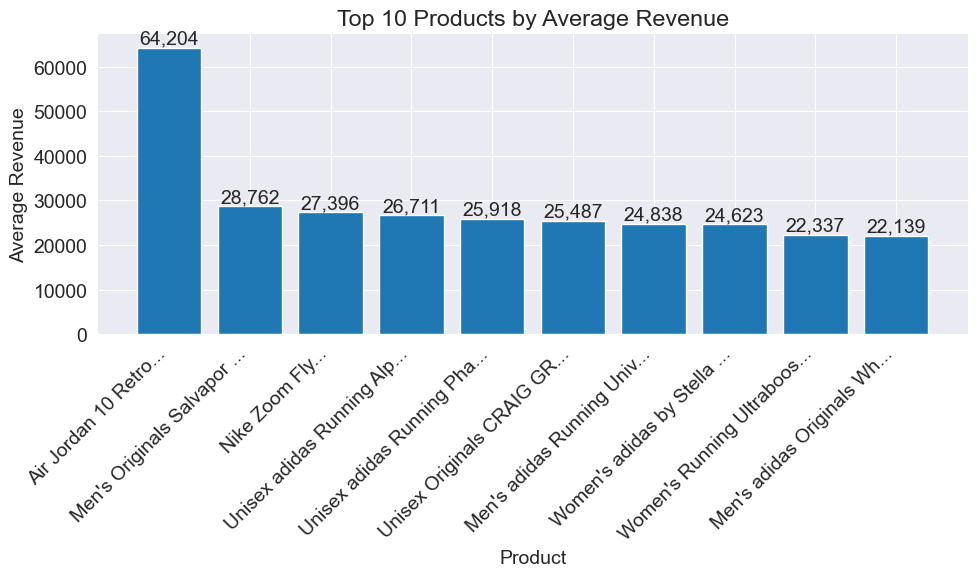

In [46]:
# Sort and select top 10
top_revenue = avg_revenue.sort_values(
    by="avg_revenue", ascending=False
).head(10)

# Shorten long product names
top_revenue["short_name"] = top_revenue["product_name"].str[:25] + "..."

plt.figure(figsize=(10,6))
bars = plt.bar(top_revenue["short_name"], top_revenue["avg_revenue"])

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             f'{height:,.0f}',
             ha='center',
             va='bottom')

plt.xticks(rotation=45, ha='right')
plt.title("Top 10 Products by Average Revenue")
plt.xlabel("Product")
plt.ylabel("Average Revenue")
plt.tight_layout()
plt.show()



In [47]:
avg_rating=pd.read_sql("""SELECT i.product_name,
AVG(r.real_rating) AS avg_rating FROM info i
JOIN reviews r ON i.product_id=r.product_id
GROUP BY i.product_name
ORDER BY avg_rating DESC
LIMIT 10;""",conn)
avg_rating

,product_name,avg_rating
0,Zoom Freak 1 'Employee of the Month',5.0
1,Women's adidas by Steall Mccartney Running Ult...,5.0
2,Women's adidas Training FitBounce Trainers,5.0
3,Women's adidas Sport Inspired Energy Cloud V S...,5.0
4,Women's adidas Running Duramo SL Shoes,5.0
5,Women's Running Boston Shoes,5.0
6,Women's ADIDAS ORIGINALS NMD_CS2 PK SHOES,5.0
7,Women's ADIDAS ORIGINALS COURTVANTAGE VULCANIZ...,5.0
8,WoMEN'S adidas RUNNING supernova SHOES,5.0
9,WOMEN'S ADIDAS SPORT INSPIRED ULTIMAMOTION SHOES,5.0


Products with higher review volumes demonstrate stronger customer engagement and visibility. These products often benefit from social proof, which can positively influence future purchasing decisions.

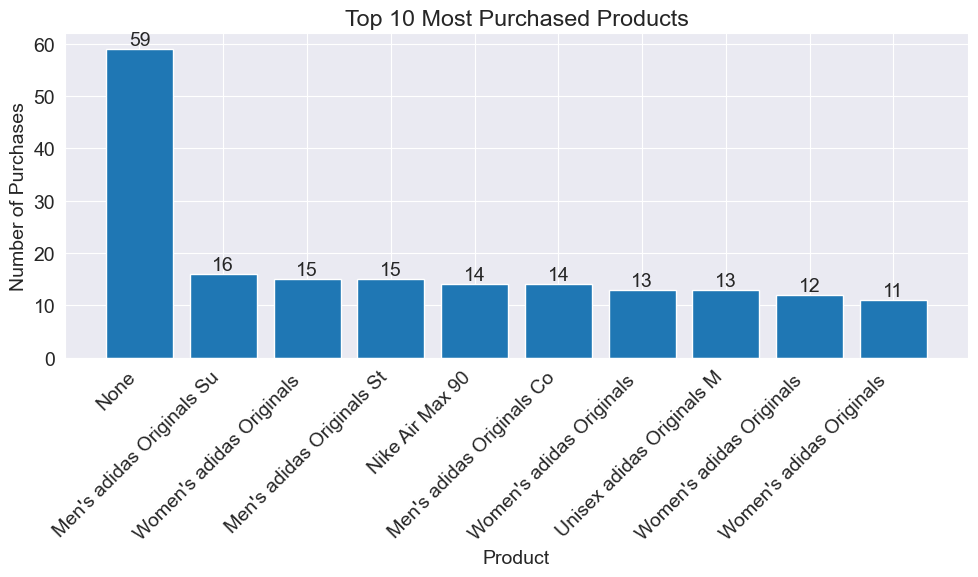

In [50]:
import matplotlib.pyplot as plt

# Sort and select top 10 most purchased products
top_purchased = (
    most_products_purchased
    .sort_values(by="count_of_products", ascending=False)
    .head(10)
    .copy()
)

# Shorten long product names safely
top_purchased["short_name"] = top_purchased["product_name"].str.slice(0, 25)

# Create figure
plt.figure(figsize=(10, 6))

# Use numeric positions to avoid overlapping bars
x_positions = range(len(top_purchased))

bars = plt.bar(
    x_positions,
    top_purchased["count_of_products"]
)

# Add value labels on top of bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(
        i,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom"
    )

# Set x-axis labels
plt.xticks(
    x_positions,
    top_purchased["short_name"],
    rotation=45,
    ha="right"
)

# Titles and labels
plt.title("Top 10 Most Purchased Products")
plt.xlabel("Product")
plt.ylabel("Number of Purchases")

plt.tight_layout()
plt.show()

In [49]:
most_last_visited_product_in_months=pd.read_sql("""SELECT i.product_name,
    COUNT (DISTINCT SUBSTR(t.modified_last_visited,6,2)) AS year_month,
    COUNT(*) AS visit_count
FROM traffic t
JOIN info i ON t.product_id = i.product_id
GROUP BY i.product_name
ORDER BY visit_count DESC
LIMIT 10;
""",conn)

most_last_visited_product_in_months

,product_name,year_month,visit_count
0,None,12,59
1,Men's adidas Originals Supercourt Shoes,9,16
2,Women's adidas Originals Sambarose Shoes,5,15
3,Men's adidas Originals Stan Smith Shoes,8,15
4,Nike Air Max 90,9,14
5,Men's adidas Originals Continental 80 Shoes,9,14
6,Women's adidas Originals Sleek Shoes,6,13
7,Unisex adidas Originals Marathon Tech Shoes,7,13
8,Women's adidas Originals NMD_R1 Shoes,6,12
9,Women's adidas Originals Continental 80 Shoes,8,11


High average ratings are not always associated with the most frequently reviewed products. This suggests that some niche products deliver excellent customer satisfaction despite lower sales volumes.

Key Findings

A small group of products dominates sales and revenue performance.

High pricing alone does not guarantee high revenue — sales volume is critical.

Several products attract significant traffic but underperform in sales, indicating conversion inefficiencies.

Customer reviews and ratings strongly influence product visibility and perceived value.

Some high-quality products remain under-promoted despite strong customer satisfaction.

Overview

This analysis explores revenue performance across products, brands, pricing strategy, discounting behaviour, and customer review impact to identify key commercial drivers and optimisation opportunities.

The objective was to determine what factors most strongly influence revenue performance and where strategic improvements could be made.

Key Findings

Revenue Concentration in Flagship Products

Revenue is heavily concentrated in a small number of premium running and lifestyle footwear products, particularly within the Ultraboost and Originals lines.
Top-performing models generate disproportionately high revenue compared to the broader product portfolio.

Brand Dominance

Adidas accounts for the overwhelming majority of total revenue (~93%+), indicating strong brand performance but also significant brand concentration risk.

Discount Strategy Trade-Off

Discounted products generate higher total revenue overall; however, non-discounted products generate higher average revenue per product.

This suggests:

Discounts drive volume.

Full-priced items preserve stronger per-product revenue performance.

A balanced pricing strategy appears optimal.

Price Does Not Guarantee Revenue

High-priced products show inconsistent revenue performance.

Some premium models perform exceptionally well, while others underperform significantly despite similar price levels.
This indicates that perceived value and brand appeal matter more than price alone.

Strong Impact of Social Proof

Products with high review volumes generate significantly higher average revenue compared to low-review products.

This suggests that customer trust and social validation play a major role in purchasing decisions.

 Strategic Recommendations

Focus marketing efforts on high-performing flagship models while reducing over-reliance on a narrow product range.

Implement targeted review-generation campaigns to improve revenue performance of low-review products.

Maintain moderate discounting strategies rather than aggressive discounting.

Conduct price optimisation testing on underperforming premium products.

Monitor brand concentration risk and explore diversification opportunities.